In [1]:
import rdkit
import rdkit.Chem as Chem
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn

In [2]:
data = pd.read_csv("aromatase_inhibitors.csv") #reference library
data.head()

,Molecule ChEMBL ID,Smiles,pChEMBL Value
0,CHEMBL1170678,COc1cc(/C=C(\Cn2ccnc2)c2ccc([N+](=O)[O-])cc2)c...,7.16
1,CHEMBL308537,CO[C@@H]1CC2C3CCC(=O)C3(C)CCC2C2(C)CCCC=C12,9.89
2,CHEMBL1083353,O=c1c2ccccc2sc2c(Cn3ccnc3)cccc12,8.40
3,CHEMBL454705,CC1=C[C@@H]2c3c(O)cc(-c4cc5ccc(O)cc5o4)cc3O[C@...,5.12
4,CHEMBL457679,CC(C)=CCc1cc(-c2oc3cc(O)cc(O)c3c(=O)c2O)ccc1O,7.00


In [4]:
colnames = ['SMILES', 'CHEMBL_ID']   #1.5 million small molecule library
chembl_db = pd.read_csv("chembl_22_clean_1576904_sorted_std_final.smi", sep='\t', names=colnames, header=None)
chembl_db.shape


(1576904, 2)

In [5]:
chembl_db

,SMILES,CHEMBL_ID
0,CCO,CHEMBL545
1,C,CHEMBL17564
2,CO,CHEMBL14688
3,NCCS,CHEMBL602
4,NCCN,CHEMBL816
...,...,...
1576899,CC1=CN(C2CC(OP(O)(=O)OCC3OC(C(O)C3OP(O)(=O)OCC...,CHEMBL1077161
1576900,CC1=CN(C2CC(OP(O)(=O)OCC3OC(C(O)C3OP(O)(=O)OCC...,CHEMBL1077162
1576901,n1(cnc2c1N=C(N)NC2=O)C1OC(COP(O)(=O)OC2C(COP(O...,CHEMBL1077165
1576902,CC1=CN(C2CC(OP(O)(=O)OCC3OC(C(O)C3OP(O)(=O)OCC...,CHEMBL1077164


In [6]:

from rdkit.Chem import Descriptors
from tqdm import tqdm
# empty dictionary for pandasCalcExactMolWt, CalcCrippenDescriptors, 
properties = {"Name": [], "MinEStateIndex":[], "BCUT2D_MWHI":[], "BCUT2D_MRHI":[], "BCUT2D_MRLOW": [], 
              "PEOE_VSA1": [], "PEOE_VSA10": [], "PEOE_VSA12": [], "PEOE_VSA2": [], 
              "SMR_VSA3": [], "SMR_VSA4": [], "SMR_VSA5": [], "SlogP_VSA1": [], "SlogP_VSA3": [], 
              "SlogP_VSA4": [], "EState_VSA10": [],}


# Assuming chembl_db is your DataFrame
for idx, smiles in enumerate(tqdm(chembl_db['SMILES'][1:1000])):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        continue
    properties["MinEStateIndex"].append(Descriptors.MinEStateIndex(mol))
    properties["BCUT2D_MWHI"].append(Descriptors.BCUT2D_MWHI(mol))
    properties["BCUT2D_MRHI"].append(Descriptors.BCUT2D_MRHI(mol))
    properties["BCUT2D_MRLOW"].append(Descriptors.BCUT2D_MRLOW(mol))
    properties["PEOE_VSA1"].append(Descriptors.PEOE_VSA1(mol))
    properties["PEOE_VSA10"].append(Descriptors.PEOE_VSA10(mol))
    properties["PEOE_VSA12"].append(Descriptors.PEOE_VSA12(mol))
    properties["PEOE_VSA2"].append(Descriptors.PEOE_VSA2(mol))
    properties["SMR_VSA3"].append(Descriptors.SMR_VSA3(mol))
    properties["SMR_VSA4"].append(Descriptors.SMR_VSA4(mol))
    properties["SMR_VSA5"].append(Descriptors.SMR_VSA5(mol))
    properties["SlogP_VSA1"].append(Descriptors.SlogP_VSA1(mol))
    properties["SlogP_VSA3"].append(Descriptors.SlogP_VSA3(mol))
    properties["SlogP_VSA4"].append(Descriptors.SlogP_VSA4(mol))
    properties["EState_VSA10"].append(Descriptors.EState_VSA10(mol))
    properties["Name"].append(chembl_db['CHEMBL_ID'].iloc[idx])



100%|██████████| 999/999 [00:01<00:00, 544.62it/s]


In [7]:
chembl_new = pd.DataFrame(properties)

In [8]:
chembl_new

,Name,MinEStateIndex,BCUT2D_MWHI,BCUT2D_MRHI,BCUT2D_MRLOW,PEOE_VSA1,PEOE_VSA10,PEOE_VSA12,PEOE_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SlogP_VSA1,SlogP_VSA3,SlogP_VSA4,EState_VSA10
0,CHEMBL545,0.000000,12.011000,2.503000,2.503000,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,7.426653,0.000000,0.000000,0.000000,0.000000
1,CHEMBL17564,1.000000,16.235703,3.177807,0.398993,5.106527,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,CHEMBL14688,0.683642,32.116866,7.797751,1.156191,5.733667,0.000000,0.0,0.000000,0.00000,5.733667,0.000000,5.733667,0.000000,0.000000,0.000000
3,CHEMBL602,0.597222,14.627759,4.255808,0.976215,11.467335,0.000000,0.0,0.000000,0.00000,11.467335,0.000000,11.467335,0.000000,0.000000,0.000000
4,CHEMBL816,1.500000,14.421800,3.537194,1.477806,5.733667,0.000000,0.0,0.000000,0.00000,5.733667,0.000000,5.733667,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,CHEMBL354077,1.041667,32.181139,8.227758,0.571849,4.899910,4.320534,0.0,0.000000,4.89991,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
994,CHEMBL397404,0.815139,16.128433,5.639266,-0.103631,0.000000,6.286161,0.0,4.794537,0.00000,0.000000,26.186202,0.000000,4.794537,0.000000,4.794537
995,CHEMBL454759,0.956944,79.919760,9.091544,1.706223,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
996,CHEMBL1324439,1.125000,14.225056,5.112004,1.516030,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,22.662226,0.000000


In [9]:
for idx, smiles in enumerate(chembl_db['SMILES']):
    mol = Chem.MolFromSmiles(chembl_db['SMILES'][idx])
    
    print(Descriptors.MinEStateIndex(mol))
    if idx > 6:
        break
    

0.25
0.0
1.0
0.683641975308642
0.5972222222222222
1.5
2.0
0.75


In [10]:
for idx, smiles in enumerate(chembl_db['SMILES']):
    print(smiles)
    if idx > 6:
        break

CCO
C
CO
NCCS
NCCN
CN
C=O
CCN


In [11]:

import numpy as np
import pandas as pd
import rdkit as rk
from rdkit import Chem 
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors

In [12]:
new = chembl_db.iloc[:1000,:]

In [13]:
new

,SMILES,CHEMBL_ID
0,CCO,CHEMBL545
1,C,CHEMBL17564
2,CO,CHEMBL14688
3,NCCS,CHEMBL602
4,NCCN,CHEMBL816
...,...,...
995,CN1CCSC1=S,CHEMBL397404
996,CCCCC=CC=O,CHEMBL454759
997,BrCC=CCBr,CHEMBL1324439
998,N#CC=CC#N,CHEMBL1451833


In [14]:
%%time
#Create a RDkit molecule instance for each smiles
new['Molecule'] = new['SMILES'].apply(Chem.MolFromSmiles)

new

CPU times: user 20.4 ms, sys: 7.34 ms, total: 27.8 ms
Wall time: 30.3 ms


[09:40:50] Explicit valence for atom # 1 N, 6, is greater than permitted
<timed exec>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,SMILES,CHEMBL_ID,Molecule
0,CCO,CHEMBL545,<rdkit.Chem.rdchem.Mol object at 0x31997e1f0>
1,C,CHEMBL17564,<rdkit.Chem.rdchem.Mol object at 0x31997df50>
2,CO,CHEMBL14688,<rdkit.Chem.rdchem.Mol object at 0x31997e260>
3,NCCS,CHEMBL602,<rdkit.Chem.rdchem.Mol object at 0x31997e490>
4,NCCN,CHEMBL816,<rdkit.Chem.rdchem.Mol object at 0x31997e420>
...,...,...,...
995,CN1CCSC1=S,CHEMBL397404,<rdkit.Chem.rdchem.Mol object at 0x173f41a10>
996,CCCCC=CC=O,CHEMBL454759,<rdkit.Chem.rdchem.Mol object at 0x173f41a80>
997,BrCC=CCBr,CHEMBL1324439,<rdkit.Chem.rdchem.Mol object at 0x173f41af0>
998,N#CC=CC#N,CHEMBL1451833,<rdkit.Chem.rdchem.Mol object at 0x173f41b60>


In [15]:
new.isna().sum()

SMILES       0
CHEMBL_ID    0
Molecule     1
dtype: int64

In [16]:
# Check for any rows with NaN values
rows_with_nan = new[new.isnull().any(axis=1)]

# Display rows with NaN values
print(rows_with_nan)


          SMILES   CHEMBL_ID Molecule
667  O=[N](=O)=O  CHEMBL1352     None


In [17]:
new = new.dropna()

In [18]:
new.isna().sum()

SMILES       0
CHEMBL_ID    0
Molecule     0
dtype: int64

In [19]:
des_list = [x[0] for x in Descriptors._descList]
len(des_list)

df_new = new

In [20]:
calculator = MoleculeDescriptors.MolecularDescriptorCalculator(des_list)
descriptors = [calculator.CalcDescriptors(mol) for mol in df_new['Molecule']]

# Create a new DataFrame with descriptors
descriptors_df = pd.DataFrame(descriptors, columns=des_list)

# Concatenate the original DataFrame with the descriptors DataFrame
df_with_descriptors = pd.concat([df_new, descriptors_df], axis=1)

# Display the resulting DataFrame
df_with_descriptors.head()

[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerator
[09:41:48] DEPRECATION WARNING: please use MorganGenerat

,SMILES,CHEMBL_ID,Molecule,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,CCO,CHEMBL545,<rdkit.Chem.rdchem.Mol object at 0x31997e1f0>,7.569444,7.569444,0.250000,0.250000,0.406808,6.0,46.069,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C,CHEMBL17564,<rdkit.Chem.rdchem.Mol object at 0x31997df50>,0.000000,0.000000,0.000000,0.000000,0.359785,0.0,16.043,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CO,CHEMBL14688,<rdkit.Chem.rdchem.Mol object at 0x31997e260>,7.000000,7.000000,1.000000,1.000000,0.385284,3.0,32.042,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,NCCS,CHEMBL602,<rdkit.Chem.rdchem.Mol object at 0x31997e490>,4.951389,4.951389,0.683642,0.683642,0.419021,7.5,77.152,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,NCCN,CHEMBL816,<rdkit.Chem.rdchem.Mol object at 0x31997e420>,4.902778,4.902778,0.597222,0.597222,0.403496,7.5,60.100,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
import pandas as pd
from rdkit import Chem
from rdkit.ML.Descriptors import MoleculeDescriptors
from tqdm import tqdm

# Assuming df_new['Molecule'] contains RDKit molecule objects

# Initialize the descriptor calculator
calculator = MoleculeDescriptors.MolecularDescriptorCalculator(des_list)

# Chunk size for processing
chunk_size = 100  # Adjust the chunk size as needed

# Calculate descriptors in chunks
chunks = [new.iloc[i:i + chunk_size] for i in range(0, len(new), chunk_size)]

# Create an empty list to store descriptors
descriptors = []

# Iterate through each chunk
for chunk in tqdm(chunks, desc="Calculating descriptors", total=len(chunks)):
    # Calculate descriptors for molecules in the chunk
    chunk_descriptors = [calculator.CalcDescriptors(mol) for mol in chunk['Molecule']]
    descriptors.extend(chunk_descriptors)

# Create a DataFrame from descriptors
descriptors_df = pd.DataFrame(descriptors, columns=des_list)

# Concatenate original DataFrame with descriptors DataFrame
chembl_with_descriptors = pd.concat([new.reset_index(drop=True), descriptors_df.reset_index(drop=True)], axis=1)

# Display the resulting DataFrame
chembl_with_descriptors.head()


Calculating descriptors: 100%|██████████| 10/10 [00:13<00:00,  1.32s/it]


,SMILES,CHEMBL_ID,Molecule,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,CCO,CHEMBL545,<rdkit.Chem.rdchem.Mol object at 0x00000178473...,7.569444,7.569444,0.250000,0.250000,0.406808,6.0,46.069,...,0,0,0,0,0,0,0,0,0,0
1,C,CHEMBL17564,<rdkit.Chem.rdchem.Mol object at 0x00000178473...,0.000000,0.000000,0.000000,0.000000,0.359785,0.0,16.043,...,0,0,0,0,0,0,0,0,0,0
2,CO,CHEMBL14688,<rdkit.Chem.rdchem.Mol object at 0x00000178473...,7.000000,7.000000,1.000000,1.000000,0.385284,3.0,32.042,...,0,0,0,0,0,0,0,0,0,0
3,NCCS,CHEMBL602,<rdkit.Chem.rdchem.Mol object at 0x00000178473...,4.951389,4.951389,0.683642,0.683642,0.419021,7.5,77.152,...,0,0,0,0,0,0,0,0,0,0
4,NCCN,CHEMBL816,<rdkit.Chem.rdchem.Mol object at 0x00000178473...,4.902778,4.902778,0.597222,0.597222,0.403496,7.5,60.100,...,0,0,0,0,0,0,0,0,0,0


In [21]:
df_with_descriptors

,SMILES,CHEMBL_ID,Molecule,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,CCO,CHEMBL545,<rdkit.Chem.rdchem.Mol object at 0x31997e1f0>,7.569444,7.569444,0.250000,0.250000,0.406808,6.000000,46.069,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C,CHEMBL17564,<rdkit.Chem.rdchem.Mol object at 0x31997df50>,0.000000,0.000000,0.000000,0.000000,0.359785,0.000000,16.043,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CO,CHEMBL14688,<rdkit.Chem.rdchem.Mol object at 0x31997e260>,7.000000,7.000000,1.000000,1.000000,0.385284,3.000000,32.042,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,NCCS,CHEMBL602,<rdkit.Chem.rdchem.Mol object at 0x31997e490>,4.951389,4.951389,0.683642,0.683642,0.419021,7.500000,77.152,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,NCCN,CHEMBL816,<rdkit.Chem.rdchem.Mol object at 0x31997e420>,4.902778,4.902778,0.597222,0.597222,0.403496,7.500000,60.100,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,CCCCC=CC=O,CHEMBL454759,<rdkit.Chem.rdchem.Mol object at 0x173f41a80>,3.242708,3.242708,0.956944,0.956944,0.488276,10.333333,213.900,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
997,BrCC=CCBr,CHEMBL1324439,<rdkit.Chem.rdchem.Mol object at 0x173f41af0>,7.709444,7.709444,1.125000,1.125000,0.397904,7.000000,78.074,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
998,N#CC=CC#N,CHEMBL1451833,<rdkit.Chem.rdchem.Mol object at 0x173f41b60>,4.746029,4.746029,0.670000,0.670000,0.506498,10.750000,116.160,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
999,COCC=CCOC,CHEMBL1994550,<rdkit.Chem.rdchem.Mol object at 0x173f41bd0>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df_with_descriptors.isna().sum()

SMILES               1
CHEMBL_ID            1
Molecule             1
MaxAbsEStateIndex    1
MaxEStateIndex       1
                    ..
fr_thiazole          1
fr_thiocyan          1
fr_thiophene         1
fr_unbrch_alkane     1
fr_urea              1
Length: 213, dtype: int64

In [22]:
from rdkit.Chem.rdMolDescriptors import CalcNumLipinskiHBA, CalcNumLipinskiHBD, CalcFractionCSP3, CalcNumRotatableBonds, CalcNumRings, CalcTPSA, CalcNumAromaticRings, CalcExactMolWt, CalcCrippenDescriptors

# empty dictionary for pandasCalcExactMolWt, CalcCrippenDescriptors, 
properties = {"MW":[], "LogP":[], "HBA":[], "HBD": [], 
              "CSP3": [], "NumRotBond": [], "NumRings": [], "TPSA": [], 
              "NumAromaticRings": [], "pIC50": []}

for idx, smiles in enumerate(data['Smiles']):
    mol = Chem.MolFromSmiles(smiles)
    properties["MW"].append(CalcExactMolWt(mol))
    properties["LogP"].append(CalcCrippenDescriptors(mol)[0])
    properties["HBA"].append(CalcNumLipinskiHBA(mol))
    properties["HBD"].append(CalcNumLipinskiHBD(mol))
    properties["CSP3"].append(CalcFractionCSP3(mol))
    properties["NumRotBond"].append(CalcNumRotatableBonds(mol))
    properties["NumRings"].append(CalcNumRings(mol))
    properties["TPSA"].append(CalcTPSA(mol))
    properties["NumAromaticRings"].append(CalcNumAromaticRings(mol))
    properties["pIC50"].append(data['pChEMBL Value'].iloc[idx])

In [25]:
data_new = pd.DataFrame(properties)

In [26]:
from rdkit.Chem.rdMolDescriptors import CalcExactMolWt, CalcCrippenDescriptors, CalcNumLipinskiHBA, CalcNumLipinskiHBD, CalcFractionCSP3, CalcNumRotatableBonds, CalcNumRings, CalcTPSA, CalcNumAromaticRings

# empty dictionary for pandas
properties6 = {"MW":[], "LogP":[], "HBA":[], "HBD": [], 
              "CSP3": [], "NumRotBond": [], "NumRings": [], "TPSA": [], 
              "NumAromaticRings": [], "CHEMBL_ID":[],"SMILES":[]}


for idx, SMILES in enumerate(chembl_db['SMILES']):
    mol = Chem.MolFromSmiles(SMILES)
    if mol == None:
        continue
    properties6["MW"].append(CalcExactMolWt(mol))
    properties6["LogP"].append(CalcCrippenDescriptors(mol)[0])
    properties6["HBA"].append(CalcNumLipinskiHBA(mol))
    properties6["HBD"].append(CalcNumLipinskiHBD(mol))
    properties6["CSP3"].append(CalcFractionCSP3(mol))
    properties6["NumRotBond"].append(CalcNumRotatableBonds(mol))
    properties6["NumRings"].append(CalcNumRings(mol))
    properties6["TPSA"].append(CalcTPSA(mol))
    properties6["NumAromaticRings"].append(CalcNumAromaticRings(mol))
    properties6["CHEMBL_ID"].append(chembl_db['CHEMBL_ID'][idx])
    properties6["SMILES"].append(SMILES)
  

[09:43:11] Explicit valence for atom # 1 N, 6, is greater than permitted
[09:43:12] Explicit valence for atom # 3 O, 3, is greater than permitted
[09:43:12] Explicit valence for atom # 3 O, 3, is greater than permitted
[09:43:12] Explicit valence for atom # 4 O, 3, is greater than permitted
[09:43:12] Explicit valence for atom # 3 O, 3, is greater than permitted
[09:43:12] Explicit valence for atom # 3 O, 3, is greater than permitted
[09:43:12] Explicit valence for atom # 5 O, 3, is greater than permitted
[09:43:12] Explicit valence for atom # 5 O, 3, is greater than permitted
[09:43:12] Explicit valence for atom # 4 O, 3, is greater than permitted
[09:43:12] Explicit valence for atom # 4 O, 3, is greater than permitted
[09:43:13] Explicit valence for atom # 4 O, 3, is greater than permitted
[09:43:13] Explicit valence for atom # 5 O, 3, is greater than permitted
[09:43:14] Explicit valence for atom # 5 O, 3, is greater than permitted
[09:43:14] Explicit valence for atom # 8 O, 3, is g

In [27]:
chembl_data = pd.DataFrame(properties6)

In [28]:
chembl_data_t = chembl_data.iloc[:, :-2]
chembl_data_t

,MW,LogP,HBA,HBD,CSP3,NumRotBond,NumRings,TPSA,NumAromaticRings
0,46.041865,-0.00140,1,1,1.000000,0,0,20.23,0
1,16.031300,0.63610,0,0,1.000000,0,0,0.00,0
2,32.026215,-0.39150,1,1,1.000000,0,0,20.23,0
3,77.029920,-0.12510,1,2,1.000000,1,0,26.02,0
4,60.068748,-1.09620,2,4,1.000000,1,0,52.04,0
...,...,...,...,...,...,...,...,...,...
1575722,9745.484445,-28.69698,316,117,0.498371,172,81,4497.11,49
1575723,9745.484445,-28.69698,316,117,0.498371,172,81,4497.11,49
1575724,10183.567262,-27.95436,327,119,0.495385,179,85,4635.42,51
1575725,10092.536296,-30.16516,327,120,0.503145,178,84,4638.22,50


In [29]:
X = data_new.iloc[:, :-1]
y = data_new.iloc[:, -1] 

In [30]:
y

0        7.16
1        9.89
2        8.40
3        5.12
4        7.00
        ...  
2290     4.97
2291     8.70
2292     6.29
2293     5.72
2294    10.05
Name: pIC50, Length: 2295, dtype: float64

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define the model
my_model = RandomForestRegressor(random_state=100)

# Create 5-fold cross-validation object
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation with scoring set to MSE (negative because cross_val_score minimizes the score)
mse_scores = cross_val_score(my_model, X, y, cv=kfold, scoring='neg_mean_squared_error')
r2_scores = cross_val_score(my_model, X, y, cv=kfold, scoring='r2')
mae_scores = cross_val_score(my_model, X, y, cv=kfold, scoring='neg_mean_absolute_error')

# Convert MSE to positive by taking the absolute values
mse_scores = np.abs(mse_scores)
mae_scores = np.abs(mae_scores)
# Output the results
print(f'Mean MSE from 5-fold cross-validation: {np.mean(mse_scores)}')
print(f'Standard deviation of MSE: {np.std(mse_scores)}')
print(f'Mean R² from 5-fold cross-validation: {np.mean(r2_scores)}')
print(f'Standard deviation of R²: {np.std(r2_scores)}')
print(f'Mean MAE from 5-fold cross-validation: {np.mean(mae_scores)}')
print(f'Standard deviation of MAE: {np.std(mae_scores)}')

# Train-test split as a secondary validation step (optional but often used in studies)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model on the training set
my_model.fit(X_train, y_train)

# Predict on the test set
y_pred = my_model.predict(X_test)

# Compute and print evaluation metrics on test set
mse_test = mean_squared_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)
mae_test = mean_absolute_error(y_test, y_pred)

print(f'Test MSE: {mse_test}')
print(f'Test R²: {r2_test}')
print(f'Test MAE: {mae_test}')


Mean MSE from 5-fold cross-validation: 0.8314014707574506
Standard deviation of MSE: 0.06452638521292911
Mean R² from 5-fold cross-validation: 0.4819849142773234
Standard deviation of R²: 0.03200193468965266
Mean MAE from 5-fold cross-validation: 0.6466012069804308
Standard deviation of MAE: 0.02808685974992628
Test MSE: 0.9107491027014881
Test R²: 0.46847223589493825
Test MAE: 0.6641378972960794


In [37]:
data_new.shape

(2295, 10)

In [38]:
my_model.fit(X_train, y_train)

RandomForestRegressor(random_state=100)

In [39]:
y_test_pred = my_model.predict(X_test)
y_train_pred = my_model.predict(X_train)

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)

mse_test = mean_squared_error(y_test, y_test_pred, squared=True)
mse_train = mean_squared_error(y_train, y_train_pred, squared=True)

rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
rmse_train = mean_squared_error(y_train, y_train_pred, squared= False)

r2_test = r2_score(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"Test Data: R\u00b2 = {r2_test}, MAE = {mae_test}, MSE = {mse_test}, RMSE = {rmse_test}")
print(f"Train DataR\u00b2 = {r2_train}, MAE = {mae_train}, MSE = {mse_train}, RMSE = {rmse_train}")



Test Data: R² = 0.46847223589493825, MAE = 0.6641378972960794, MSE = 0.9107491027014881, RMSE = 0.9543317571481565
Train DataR² = 0.8307948290630451, MAE = 0.34208947367109344, MSE = 0.2670804345128984, RMSE = 0.5167982532022515


/Users/sefunmibodun/anaconda3/envs/dami/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/sefunmibodun/anaconda3/envs/dami/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/sefunmibodun/anaconda3/envs/dami/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/sefunmibodun/anaconda3/envs/dami/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is 

In [41]:
chembl_data_t = chembl_data.iloc[:, :-2]
chembl_data_t

,MW,LogP,HBA,HBD,CSP3,NumRotBond,NumRings,TPSA,NumAromaticRings
0,46.041865,-0.00140,1,1,1.000000,0,0,20.23,0
1,16.031300,0.63610,0,0,1.000000,0,0,0.00,0
2,32.026215,-0.39150,1,1,1.000000,0,0,20.23,0
3,77.029920,-0.12510,1,2,1.000000,1,0,26.02,0
4,60.068748,-1.09620,2,4,1.000000,1,0,52.04,0
...,...,...,...,...,...,...,...,...,...
1575722,9745.484445,-28.69698,316,117,0.498371,172,81,4497.11,49
1575723,9745.484445,-28.69698,316,117,0.498371,172,81,4497.11,49
1575724,10183.567262,-27.95436,327,119,0.495385,179,85,4635.42,51
1575725,10092.536296,-30.16516,327,120,0.503145,178,84,4638.22,50


In [42]:
y_pred_chembl = my_model.predict(chembl_data_t)
y_pred_chembl

array([5.01021706, 5.10440373, 5.02488373, ..., 5.44084643, 5.44084643,
       5.44084643])

In [43]:
colname = ['pIC50']
pic50_df = pd.DataFrame(y_pred_chembl, columns=colname)

In [44]:
chembl_data.head()

,MW,LogP,HBA,HBD,CSP3,NumRotBond,NumRings,TPSA,NumAromaticRings,CHEMBL_ID,SMILES
0,46.041865,-0.0014,1,1,1.0,0,0,20.23,0,CHEMBL545,CCO
1,16.031300,0.6361,0,0,1.0,0,0,0.00,0,CHEMBL17564,C
2,32.026215,-0.3915,1,1,1.0,0,0,20.23,0,CHEMBL14688,CO
3,77.029920,-0.1251,1,2,1.0,1,0,26.02,0,CHEMBL602,NCCS
4,60.068748,-1.0962,2,4,1.0,1,0,52.04,0,CHEMBL816,NCCN


In [45]:
total_chembl = pd.concat([chembl_data, pic50_df], axis=1)

In [46]:
total_chembl

,MW,LogP,HBA,HBD,CSP3,NumRotBond,NumRings,TPSA,NumAromaticRings,CHEMBL_ID,SMILES,pIC50
0,46.041865,-0.00140,1,1,1.000000,0,0,20.23,0,CHEMBL545,CCO,5.010217
1,16.031300,0.63610,0,0,1.000000,0,0,0.00,0,CHEMBL17564,C,5.104404
2,32.026215,-0.39150,1,1,1.000000,0,0,20.23,0,CHEMBL14688,CO,5.024884
3,77.029920,-0.12510,1,2,1.000000,1,0,26.02,0,CHEMBL602,NCCS,4.994821
4,60.068748,-1.09620,2,4,1.000000,1,0,52.04,0,CHEMBL816,NCCN,5.076071
...,...,...,...,...,...,...,...,...,...,...,...,...
1575722,9745.484445,-28.69698,316,117,0.498371,172,81,4497.11,49,CHEMBL1077161,CC1=CN(C2CC(OP(O)(=O)OCC3OC(C(O)C3OP(O)(=O)OCC...,5.440846
1575723,9745.484445,-28.69698,316,117,0.498371,172,81,4497.11,49,CHEMBL1077162,CC1=CN(C2CC(OP(O)(=O)OCC3OC(C(O)C3OP(O)(=O)OCC...,5.440846
1575724,10183.567262,-27.95436,327,119,0.495385,179,85,4635.42,51,CHEMBL1077165,n1(cnc2c1N=C(N)NC2=O)C1OC(COP(O)(=O)OC2C(COP(O...,5.440846
1575725,10092.536296,-30.16516,327,120,0.503145,178,84,4638.22,50,CHEMBL1077164,CC1=CN(C2CC(OP(O)(=O)OCC3OC(C(O)C3OP(O)(=O)OCC...,5.440846


In [47]:
total_chembl_sort = total_chembl.sort_values(by=['pIC50'], ascending=False)
total_chembl_sort

,MW,LogP,HBA,HBD,CSP3,NumRotBond,NumRings,TPSA,NumAromaticRings,CHEMBL_ID,SMILES,pIC50
1238981,524.026622,3.63148,9,2,0.045455,7,4,127.13,4,CHEMBL1672975,NS(=O)(=O)Oc1ccc(cc1)-c1cc(ccc1C#N)N(Cc1ccc(Br...,9.967400
1238974,524.026622,3.63148,9,2,0.045455,7,4,127.13,4,CHEMBL1672979,NS(=O)(=O)Oc1ccc(CN(c2ccc(C#N)c(c2)-c2ccccc2)n...,9.967400
1238973,480.077137,3.52238,9,2,0.045455,7,4,127.13,4,CHEMBL1672978,NS(=O)(=O)Oc1ccc(CN(c2ccc(C#N)c(c2)-c2ccccc2)n...,9.673650
1291382,504.032889,3.09152,9,2,0.047619,6,4,127.23,4,CHEMBL1996957,Cc1ccccc1S(=O)(=O)NN1C=Nc2ccc(cc2C1=O)S(=O)(=O...,9.542610
888681,387.080139,1.94608,8,2,0.058824,6,3,114.24,3,CHEMBL3623232,NS(=O)(=O)Oc1ccc(CN(c2ccc(cc2)C#N)n2ccnc2)c(F)c1,9.501548
...,...,...,...,...,...,...,...,...,...,...,...,...
80109,254.094294,3.05410,3,0,0.187500,2,3,35.53,2,CHEMBL2011181,COc1ccccc1C1COc2ccccc2C1=O,4.288685
149866,254.094294,3.05410,3,0,0.187500,2,3,35.53,2,CHEMBL1165711,COc1ccc2C(=O)C(COc2c1)c1ccccc1,4.288685
113266,254.094294,3.05410,3,0,0.187500,2,3,35.53,2,CHEMBL2011182,COc1cccc(c1)C1COc2ccccc2C1=O,4.288685
152417,254.094294,3.05410,3,0,0.187500,2,3,35.53,2,CHEMBL2011180,COc1ccc2OCC(C(=O)c2c1)c1ccccc1,4.288685


In [67]:
total_chembl_sort_high = total_chembl_sort[total_chembl_sort['pIC50'] > 8.8]
total_chembl_sort_high.shape

(147, 12)

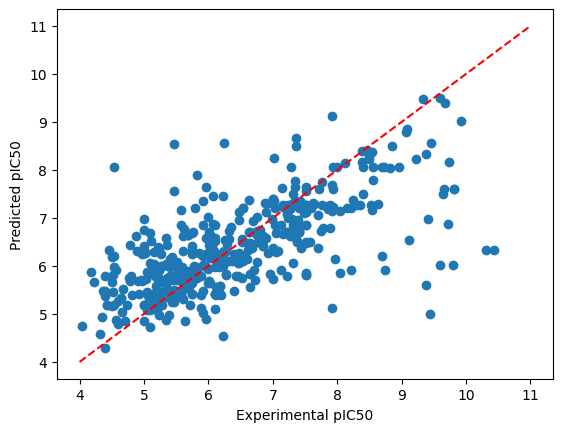

In [68]:
plt.scatter(y_test, y_test_pred)
plt.xlabel("Experimental pIC50")
plt.ylabel("Predicted pIC50")
plt.plot(range(4, 12), range(4, 12), "r--", label = "y=x")

In [69]:
my_model.feature_importances_

array([0.17096888, 0.19914341, 0.03989635, 0.04418148, 0.21029723,
       0.12362032, 0.02834517, 0.14442251, 0.03912465])

In [70]:
fea_im_df = pd.DataFrame(my_model.feature_importances_, columns=['Importance'])
fea_im_df['Features'] = ["MW", "LogP","HBA","HBD","CSP3","Num Rot Bond","Num Rings","TPSA","Num Aromatic Rings"]
finalDf = fea_im_df[['Features', 'Importance']]
finalDf.sort_values(by=['Importance'], ascending=False, ignore_index=True, inplace=True)
finalDf

,Features,Importance
0,CSP3,0.210297
1,LogP,0.199143
2,MW,0.170969
3,TPSA,0.144423
4,Num Rot Bond,0.123620
5,HBD,0.044181
6,HBA,0.039896
7,Num Aromatic Rings,0.039125
8,Num Rings,0.028345


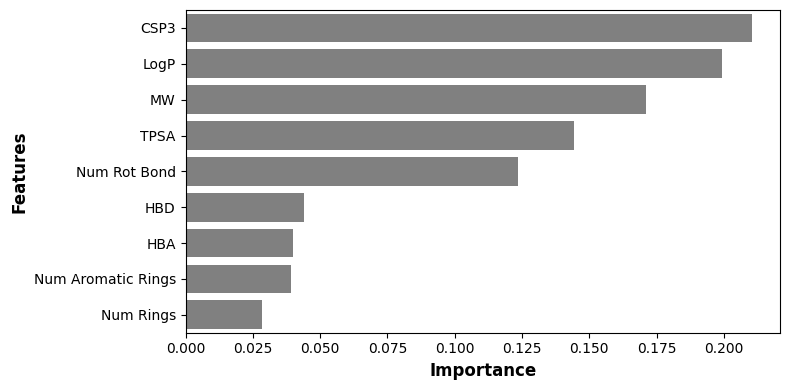

In [71]:
import seaborn as sns
fig, ax=plt.subplots(figsize=(8,4))
sns.barplot(x=finalDf['Importance'], y=finalDf['Features'], data= finalDf, color='grey')
plt.xlabel('Importance', fontsize=12, weight='bold')
plt.ylabel('Features', fontsize=12, weight='bold')
plt.tight_layout()

In [72]:
total_chembl_sort_high

,MW,LogP,HBA,HBD,CSP3,NumRotBond,NumRings,TPSA,NumAromaticRings,CHEMBL_ID,SMILES,pIC50
1238981,524.026622,3.63148,9,2,0.045455,7,4,127.13,4,CHEMBL1672975,NS(=O)(=O)Oc1ccc(cc1)-c1cc(ccc1C#N)N(Cc1ccc(Br...,9.967400
1238974,524.026622,3.63148,9,2,0.045455,7,4,127.13,4,CHEMBL1672979,NS(=O)(=O)Oc1ccc(CN(c2ccc(C#N)c(c2)-c2ccccc2)n...,9.967400
1238973,480.077137,3.52238,9,2,0.045455,7,4,127.13,4,CHEMBL1672978,NS(=O)(=O)Oc1ccc(CN(c2ccc(C#N)c(c2)-c2ccccc2)n...,9.673650
1291382,504.032889,3.09152,9,2,0.047619,6,4,127.23,4,CHEMBL1996957,Cc1ccccc1S(=O)(=O)NN1C=Nc2ccc(cc2C1=O)S(=O)(=O...,9.542610
888681,387.080139,1.94608,8,2,0.058824,6,3,114.24,3,CHEMBL3623232,NS(=O)(=O)Oc1ccc(CN(c2ccc(cc2)C#N)n2ccnc2)c(F)c1,9.501548
...,...,...,...,...,...,...,...,...,...,...,...,...
990569,386.068491,2.86120,9,1,0.058824,6,3,124.32,3,CHEMBL1705394,COc1ccc(nn1)-c1cccc(NS(=O)(=O)c2ccc(cc2)N(=O)=...,8.804642
914598,386.068491,2.86120,9,1,0.058824,6,3,124.32,3,CHEMBL1512395,COc1ccc(nn1)-c1cccc(NS(=O)(=O)c2ccccc2N(=O)=O)c1,8.804642
990271,386.068491,2.86120,9,1,0.058824,6,3,124.32,3,CHEMBL1373367,COc1ccc(nn1)-c1cccc(NS(=O)(=O)c2cccc(c2)N(=O)=...,8.804642
1322284,461.169919,2.52060,10,2,0.208333,7,3,135.22,3,CHEMBL1475892,CC(OC(=O)c1ccc(NC(=O)CC#N)cc1)C(=O)NC1=C(C)N(C...,8.802400


In [ ]:
total_chembl_sort_high.to_csv('./filtered.csv')

In [ ]:
chembl_data_t = chembl_data.iloc[:, 1:]
chembl_data_t

In [73]:
total_chembl_sort_high[total_chembl_sort_high['CHEMBL_ID'] == 'CHEMBL1429417']

,MW,LogP,HBA,HBD,CSP3,NumRotBond,NumRings,TPSA,NumAromaticRings,CHEMBL_ID,SMILES,pIC50


In [80]:
total_chembl_sort[total_chembl_sort['CHEMBL_ID'] == 'CHEMBL1410750']

,MW,LogP,HBA,HBD,CSP3,NumRotBond,NumRings,TPSA,NumAromaticRings,CHEMBL_ID,SMILES,pIC50
1238212,487.078424,2.9515,9,3,0.047619,7,3,122.31,3,CHEMBL1410750,COc1cc(NS(=O)(=O)c2ccc(NC(=S)NC(=O)C=Cc3ccc(F)...,9.328603
